# Project: Classification Model Development 🚀
This notebook explores predictive modeling using **Logistic Regression** and **K-Nearest Neighbors (KNN)**. We focus on rigorous evaluation through performance metrics and interactive visualizations.

## 1. Environment Setup & Dependencies
First, we import the essential libraries for data manipulation, machine learning, and visualization.

* **Core:** `NumPy` and `Pandas` for data handling.
* **Modeling:** `Scikit-Learn` for model selection and implementation.
* **Metrics:** A comprehensive suite including `F1-Score`, `Accuracy`, and `RMSE` for evaluation.
* **Visualization:** `Plotly` for high-quality, interactive charts.

In [46]:
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import r2_score , roc_curve , root_mean_squared_error , accuracy_score , f1_score
import plotly.graph_objects as go 
import plotly.express as px




## 2. Data Acquisition & Preliminary Exploration 🔍

In this section, we load the raw dataset and perform initial checks to understand the feature space and data consistency.

### 2.1. Dataset Loading
We load the `Social_Network_Ads` dataset. This data typically contains demographic information used to predict whether a user will purchase a product.

In [47]:
df = pd.read_csv('Social_Network_Ads.csv')

In [48]:
df.head(15)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
5,15728773,Male,27,58000,0
6,15598044,Female,27,84000,0
7,15694829,Female,32,150000,1
8,15600575,Male,25,33000,0
9,15727311,Female,35,65000,0


### 2.2. Feature Inspection & Unique Values
We examine the categorical features to understand the diversity of the labels and ensure there are no unexpected categories.

In [49]:
df['Gender'].unique().sum()

'MaleFemale'

### 2.3. Data Cleaning & Dimensionality Reduction ✂️
To optimize the model's performance and remove noise, we drop irrelevant columns.

* **Action:** Dropping `User ID` as it is a unique identifier with no statistical significance for the prediction task.


In [50]:
df = df.drop('User ID', axis= 1 )

### 2.4. Data Integrity Check (Missing Values)
Before proceeding to modeling, we must ensure the dataset is complete. A null-value check is performed to determine if imputation is required.

In [51]:
df.isnull().sum()

Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

## 3. Exploratory Data Analysis (EDA): Univariate Analysis 📊

We perform a univariate analysis to understand the distribution of individual variables and identify any anomalies or imbalances within the features and the target label.

### Key Objectives:
* **Outlier Detection:** Using Box Plots for `Age` and `EstimatedSalary` to visualize the spread and identify potential outliers that could impact distance-based models (e.g., KNN).
* **Class Balance Check:** Using a Pie Chart for the `Purchased` variable to determine if there is a class imbalance that might require specialized handling during training.

In [52]:
fig = px.box(df , x ='Age' ) 
fig

In [53]:
fig = px.box(df , x ='EstimatedSalary' ) 
fig

In [54]:
fig = px.pie(df , names= 'Purchased')
fig

## 4. Data Partitioning: Train-Test Split 🧪

Before training our models, we must split the dataset into two subsets. This prevents **overfitting** and allows us to evaluate the model's performance on unseen data, simulating a real-world scenario.

### Methodology:
* **Features (X):** The independent variables (Age, Estimated Salary, etc.) used for prediction.
* **Target (y):** The dependent variable (`Purchased`) we are trying to predict.
* **Split Ratio:** We typically use an **80/20** split to ensure the model has enough data to learn while maintaining a robust evaluation set.
* **Random State:** A fixed seed is used to ensure the results are reproducible.

In [55]:
x = df.drop('Purchased' , axis= 1)
y = df['Purchased']

In [56]:
x_trian , x_test , y_trian , y_test = train_test_split(x,y,random_state= 42 , test_size= 0.2 , stratify= y)

## 5. Feature Engineering & Data Preprocessing ⚙️

To prepare our data for Machine Learning algorithms, we must perform two essential transformations. This ensures that the mathematical models can interpret the data correctly and that no single feature dominates the others due to its scale.

### 5.1. Categorical Encoding (Label Encoding)
Since Machine Learning models operate on numerical data, we convert the `Gender` column from text (Male/Female) into a numerical format.
* **Fit-Transform:** Applied to the training set to learn and apply the mapping.
* **Transform:** Applied to the test set using the mapping learned from the training data to avoid **Data Leakage**.

### 5.2. Feature Scaling (Standardization)
Algorithms like **KNN** and **Logistic Regression** are sensitive to the scale of the data. 
* **The Problem:** `EstimatedSalary` has much larger values than `Age`, which could bias the model.
* **The Solution:** We use `StandardScaler` to shift the distribution so that the mean is 0 and the standard deviation is 1.

In [57]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
x_trian['Gender'] = encoder.fit_transform(x_trian['Gender'])

x_test['Gender'] = encoder.transform(x_test['Gender'])



In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_trian[['Age', 'EstimatedSalary']] = scaler.fit_transform(x_trian[['Age', 'EstimatedSalary']])

x_test[['Age', 'EstimatedSalary']] = scaler.transform(x_test[['Age', 'EstimatedSalary']])

print(x_trian.head())
print(x_test.head())


     Gender       Age  EstimatedSalary
65        1 -1.234462        -0.367992
179       0 -0.577646        -1.058314
109       0  0.079170         0.264803
379       0  1.955786        -1.374712
325       0  0.360662        -0.310465
     Gender       Age  EstimatedSalary
331       0  1.017478         1.386577
92        1 -1.046800        -1.604819
1         1 -0.202323        -1.461002
234       0  0.079170         1.185233
136       0 -1.609785         0.322330


## 6. Ensemble Learning: Voting Classifier 🤝

Instead of relying on a single algorithm, we implement a **Voting Classifier**. This Ensemble technique combines the predictions of multiple models to improve robustness and accuracy.

### Methodology:
* **Estimators:** We combine **Logistic Regression** (linear) and **K-Nearest Neighbors** (non-linear).
* **Voting Strategy:** We use **'Soft Voting'**. This averages the predicted probabilities of each class, giving more weight to highly confident predictions, which typically yields better results than simple majority voting.

In [61]:
log_reg = LogisticRegression()
knn = KNeighborsClassifier(n_neighbors= 5 )
ensemble = VotingClassifier(estimators=[('lr',log_reg),('knn' , knn)],
                            voting='soft'
                            )
ensemble.fit(x_trian , y_trian )


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('knn', ...)]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


🚀 Ensemble Model Accuracy: 91.25%
------------------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.92      0.93        51
           1       0.87      0.90      0.88        29

    accuracy                           0.91        80
   macro avg       0.90      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80

------------------------------


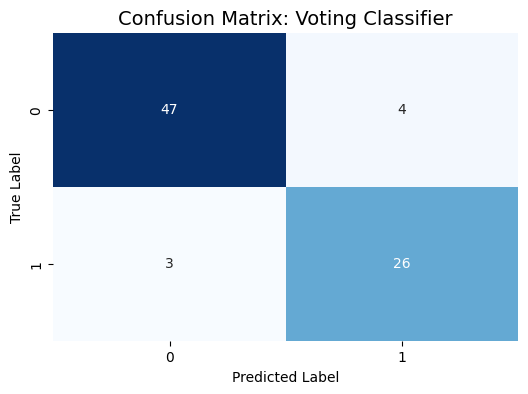

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = ensemble.predict(x_test) 

acc = accuracy_score(y_test, y_pred)
print(f"🚀 Ensemble Model Accuracy: {acc:.2%}")
print("-" * 30)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))
print("-" * 30)

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: Voting Classifier', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 7. Model Evaluation & Performance Analysis 📈

After deploying our **Voting Ensemble**, we transition to a multi-dimensional performance assessment. This phase is crucial for validating the model's generalizability on unseen data.

### 7.1. Performance Metrics Overview
We utilize a suite of metrics to ensure the model's reliability:
* **Accuracy:** Measuring the overall percentage of correct predictions.
* **Precision & Recall:** Evaluating the trade-off between the model's exactness and its ability to identify all relevant instances.
* **F1-Score:** The harmonic mean of precision and recall, providing a balanced assessment for both classes.

### 7.2. Error Analysis: Confusion Matrix 🟦
The **Confusion Matrix** provides a granular view of the model's classification performance by visualizing:
1. **True Positives (TP):** Correctly predicted purchases.
2. **True Negatives (TN):** Correctly predicted non-purchases.
3. **Type I Error (False Positives):** Predicting a purchase where there was none.
4. **Type II Error (False Negatives):** Missing a purchase that actually occurred.